# Disaster Tweet Classification
## Notebook 1: Data Exploration & Preparation
---
**Objective:** Understand the dataset structure, visualize class distributions, analyze keywords, clean text, and prepare features for modeling.

## 1. Import Libraries

In [6]:
%pip install --upgrade pip

  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 26.1.1
    Uninstalling pip-26.1.1:
      Successfully uninstalled pip-26.1.1
Note: you may need to restart the kernel to use updated packages.


In [7]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 1.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import re
import string
import warnings
import os
import pickle

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from collections import Counter
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'disaster': '#E74C3C', 'non_disaster': '#2ECC71'}

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Dataset

In [20]:
df = pd.read_csv('twitter_disaster.csv')

## DATASET OVERVIEW


In [21]:
print(f'Dataset shape: {df.shape}')

print()

print(f'Columns: {df.columns.tolist()}')
df.head(10)

Dataset shape: (7613, 5)

Columns: ['id', 'keyword', 'location', 'text', 'target']


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


## 3. Data Exploration

## Project Workflow

```text
                 Dataset
                     │
                     ▼
        Data Exploration (EDA)
                     │
                     ▼
             Text Cleaning
                     │
                     ▼
          Sentiment Analysis
                     │
                     ▼
       Feature Engineering
 (TF-IDF + Meta Features)
                     │
                     ▼
          Train/Test Split
                     │
                     ▼
          Model Training
                     │
                     ▼
     Hyperparameter Tuning
                     │
                     ▼
       Model Evaluation
                     │
                     ▼
      Validation & Deployment
```

In [22]:
# Basic info
print('=== Dataset Info ===')

df.info()

print('\n=== Descriptive Statistics ===')

df.describe(include='all')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB

=== Descriptive Statistics ===


,id,keyword,location,text,target
count,7613.000000,7552,5080,7613,7613.00000
unique,NaN,221,3341,7503,NaN
top,NaN,fatalities,USA,11-Year-Old Boy Charged With Manslaughter of T...,NaN
freq,NaN,45,104,10,NaN
mean,5441.934848,NaN,NaN,NaN,0.42966
std,3137.116090,NaN,NaN,NaN,0.49506
min,1.000000,NaN,NaN,NaN,0.00000
25%,2734.000000,NaN,NaN,NaN,0.00000
50%,5408.000000,NaN,NaN,NaN,0.00000
75%,8146.000000,NaN,NaN,NaN,1.00000


## Data cleaning

In [23]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df)

=== Missing Values ===
          Missing Count  Missing %
id                    0       0.00
keyword              61       0.80
location           2533      33.27
text                  0       0.00
target                0       0.00


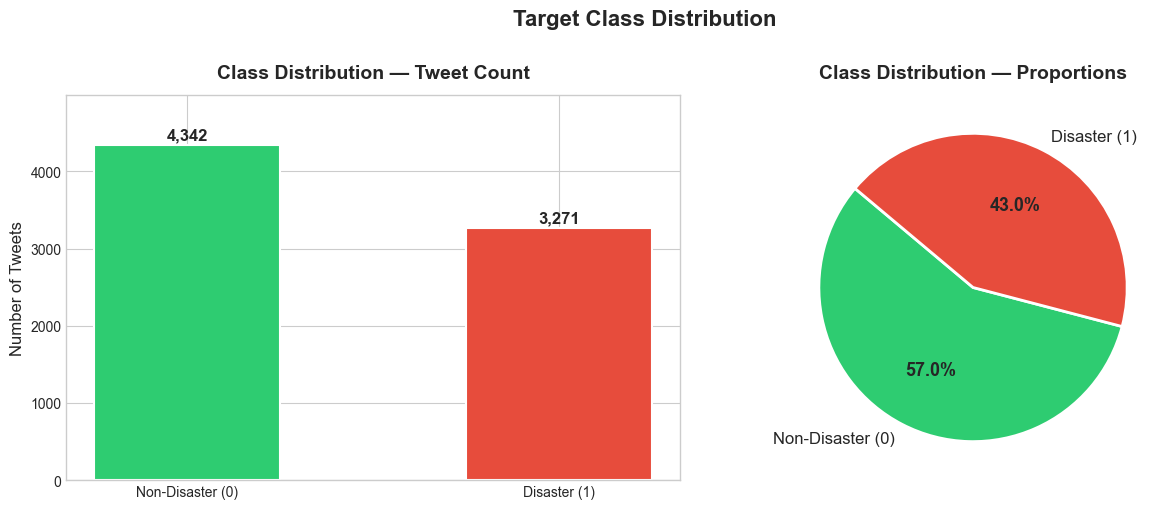

Disaster tweets:     3,271 (43.0%)
Non-disaster tweets: 4,342 (57.0%)


In [24]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['target'].value_counts()
labels = ['Non-Disaster (0)', 'Disaster (1)']
colors = [PALETTE['non_disaster'], PALETTE['disaster']]

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Class Distribution — Tweet Count', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Tweets', fontsize=12)
for bar, count in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[1].set_title('Class Distribution — Proportions', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Target Class Distribution', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/plot_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Disaster tweets:     {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(f'Non-disaster tweets: {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')



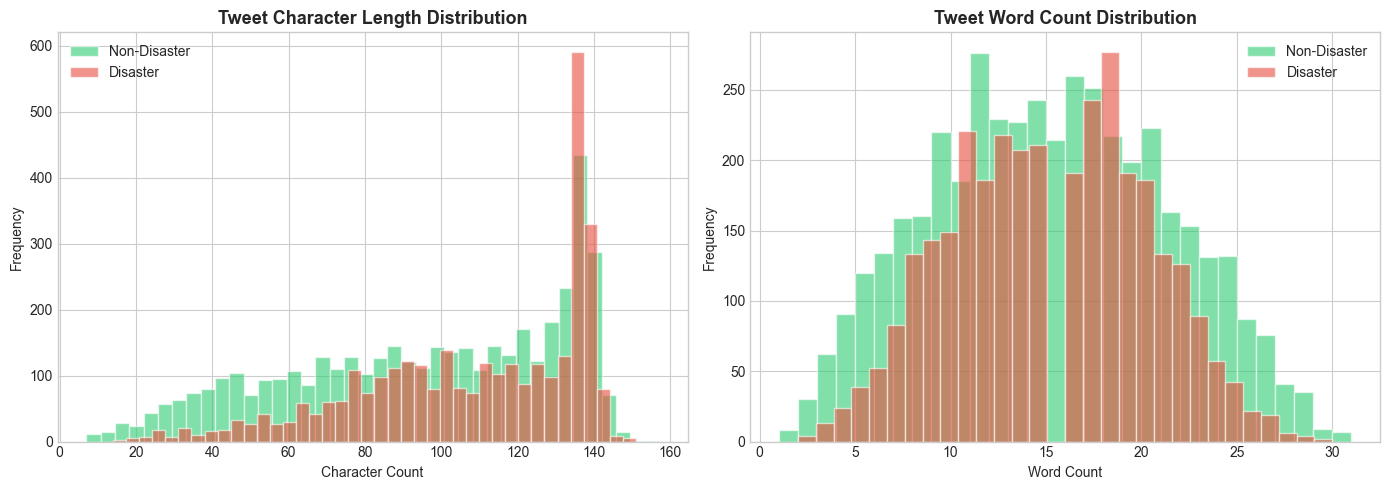

In [25]:
# Tweet length analysis
df['tweet_length'] = df['text'].apply(len)
df['word_count']   = df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target, label, color in [(0, 'Non-Disaster', PALETTE['non_disaster']),
                              (1, 'Disaster',     PALETTE['disaster'])]:
    subset = df[df['target'] == target]
    axes[0].hist(subset['tweet_length'], bins=40, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[1].hist(subset['word_count'],   bins=30, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title('Tweet Character Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count');  axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Tweet Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count');  axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/plot_tweet_length.png', dpi=150, bbox_inches='tight')
plt.show()

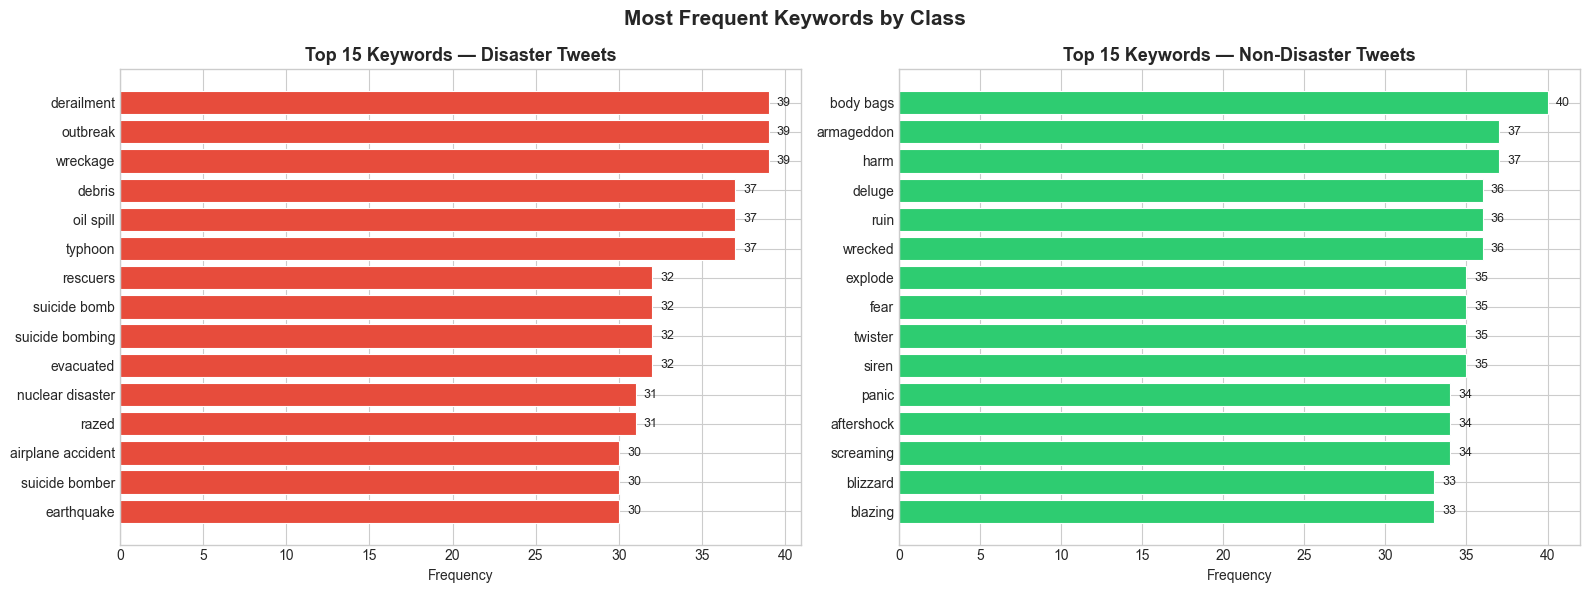

In [26]:
# Top keywords
keyword_df = df.dropna(subset=['keyword'])
keyword_df['keyword'] = keyword_df['keyword'].str.replace('%20', ' ', regex=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target, label, color in [
    (axes[0], 1, 'Disaster Tweets',     PALETTE['disaster']),
    (axes[1], 0, 'Non-Disaster Tweets', PALETTE['non_disaster'])
]:
    top_kw = keyword_df[keyword_df['target'] == target]['keyword'].value_counts().head(15)
    bars = ax.barh(top_kw.index[::-1], top_kw.values[::-1], color=color, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Top 15 Keywords — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
    for bar, val in zip(bars, top_kw.values[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

plt.suptitle('Most Frequent Keywords by Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/plot_top_keywords.png', dpi=150, bbox_inches='tight')
plt.show()

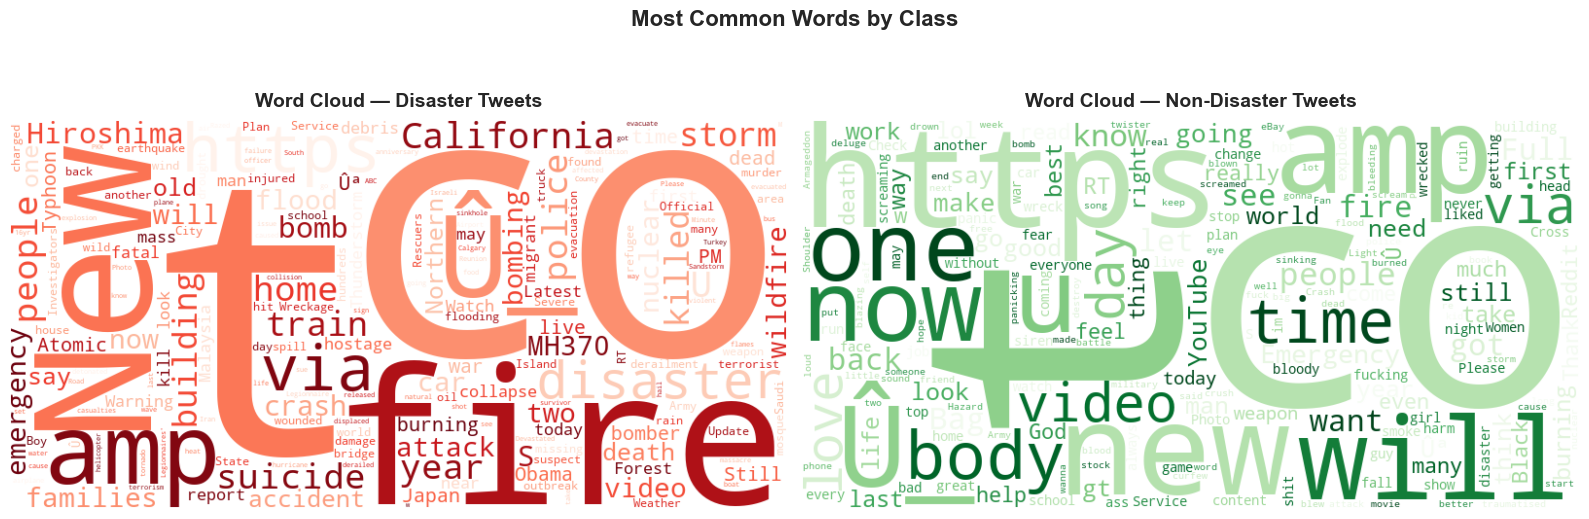

In [27]:
# Word clouds
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target, label, cmap in [
    (axes[0], 1, 'Disaster Tweets',     'Reds'),
    (axes[1], 0, 'Non-Disaster Tweets', 'Greens')
]:
    text_blob = ' '.join(df[df['target'] == target]['text'].fillna(''))
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=200,
                   collocations=False).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label}', fontsize=14, fontweight='bold', pad=10)

plt.suptitle('Most Common Words by Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/plot_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Data Preparation

In [28]:
lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

def clean_text(text):
    """Full NLP cleaning pipeline."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove mentions and hashtag symbols (keep word)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    # Remove special characters, digits, punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords & lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print('Cleaning tweets...')
df['clean_text'] = df['text'].apply(clean_text)

print('Sample before/after cleaning:')
for i in range(3):
    print(f'\n[{i}] Original: {df["text"].iloc[i]}')
    print(f'    Cleaned:  {df["clean_text"].iloc[i]}')

Cleaning tweets...
Sample before/after cleaning:

[0] Original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
    Cleaned:  deed reason earthquake may allah forgive

[1] Original: Forest fire near La Ronge Sask. Canada
    Cleaned:  forest fire near ronge sask canada

[2] Original: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
    Cleaned:  resident asked shelter place notified officer evacuation shelter place order expected


In [29]:
# Additional hand-crafted features
df['has_hashtag']  = df['text'].apply(lambda x: 1 if '#' in x else 0)
df['has_mention']  = df['text'].apply(lambda x: 1 if '@' in x else 0)
df['has_url']      = df['text'].apply(lambda x: 1 if 'http' in x.lower() else 0)
df['char_count']   = df['text'].apply(len)
df['word_count']   = df['clean_text'].apply(lambda x: len(x.split()))
df['exclaim_count']= df['text'].apply(lambda x: x.count('!'))
df['question_count']= df['text'].apply(lambda x: x.count('?'))
df['upper_ratio']  = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))

print('Extra features added:')
print(df[['has_hashtag','has_mention','has_url','char_count','word_count',
          'exclaim_count','question_count','upper_ratio']].describe().round(3))

Extra features added:
       has_hashtag  has_mention   has_url  char_count  word_count  \
count     7613.000     7613.000  7613.000    7613.000    7613.000   
mean         0.231        0.268     0.522     101.037       8.416   
std          0.422        0.443     0.500      33.781       3.395   
min          0.000        0.000     0.000       7.000       0.000   
25%          0.000        0.000     0.000      78.000       6.000   
50%          0.000        0.000     1.000     107.000       8.000   
75%          0.000        1.000     1.000     133.000      11.000   
max          1.000        1.000     1.000     157.000      21.000   

       exclaim_count  question_count  upper_ratio  
count       7613.000        7613.000     7613.000  
mean           0.154           0.411        0.100  
std            0.619           1.833        0.107  
min            0.000           0.000        0.000  
25%            0.000           0.000        0.038  
50%            0.000           0.000        

## Sentiment Analysis

In [30]:
# Sentiment Analysis Features

from textblob import TextBlob

def get_sentiment(text):
    blob = TextBlob(text)
    return pd.Series({
        "sentiment_polarity": blob.sentiment.polarity + 1,
        "sentiment_subjectivity": blob.sentiment.subjectivity
    })

# Create sentiment features
sentiment = df["clean_text"].apply(get_sentiment)

# Add the new features to the dataframe
df = pd.concat([df, sentiment], axis=1)

# Display the first few rows
df[["sentiment_polarity", "sentiment_subjectivity"]].head()

,sentiment_polarity,sentiment_subjectivity
0,1.0,0.0
1,1.1,0.4
2,0.9,0.4
3,1.0,0.0
4,1.0,0.0


In [31]:
# TF-IDF Vectorisation
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                        min_df=2, sublinear_tf=True)

X_text = tfidf.fit_transform(df['clean_text'])

# Numerical meta-features
meta_features = [
    'has_hashtag',
    'has_mention',
    'has_url',
    'char_count',
    'word_count',
    'exclaim_count',
    'question_count',
    'upper_ratio',
    'sentiment_polarity',
    'sentiment_subjectivity'
]

import scipy.sparse as sp
X_meta = sp.csr_matrix(df[meta_features].values)
X = sp.hstack([X_text, X_meta])
y = df['target'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape:  {y.shape}')

Feature matrix shape: (7613, 10010)
Target vector shape:  (7613,)


In [32]:
# Train / Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print(f'Train class balance: {np.bincount(y_train)}')
print(f'Test  class balance: {np.bincount(y_test)}')

Training set:  6,090 samples
Test set:      1,523 samples
Train class balance: [3473 2617]
Test  class balance: [869 654]


In [33]:
# Save artefacts for Notebook 2
os.makedirs('artefacts', exist_ok=True)

with open('artefacts/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

sp.save_npz('artefacts/X_train.npz', X_train)
sp.save_npz('artefacts/X_test.npz',  X_test)
np.save('artefacts/y_train.npy', y_train)
np.save('artefacts/y_test.npy',  y_test)

df[['id','text','clean_text','target'] + meta_features].to_csv('artefacts/cleaned_tweets.csv', index=False)

print('   Artefacts saved to artefacts/')
print('   → tfidf_vectorizer.pkl')
print('   → X_train.npz, X_test.npz')
print('   → y_train.npy, y_test.npy')
print('   → cleaned_tweets.csv')

   Artefacts saved to artefacts/
   → tfidf_vectorizer.pkl
   → X_train.npz, X_test.npz
   → y_train.npy, y_test.npy
   → cleaned_tweets.csv


---
##  Summary — Notebook 1

| Step | Result |
|------|--------|
| Dataset size | 7,613 tweets |
| Class balance | 57% Non-Disaster / 43% Disaster |
| Missing values | keyword (0.8%), location (33.3%), text/target (0%) |
| Text cleaning | Lowercase → URL/mention removal → Punctuation strip → Tokenise → Stop-word filter → Lemmatise |
| Feature space | TF-IDF (10k uni+bi-grams) + 8 meta-features → 10,008 dimensions |
| Split | 80% train / 20% test (stratified) |

**Proceed to Notebook 2: Feature Engineering & Model Training**